# Exploring report.csv

Open this notebook with:

```bash
uv run --with jupyter --with pandas --with matplotlib jupyter notebook explore_report.ipynb
```

The CSV has two row types:
- **`file`** — one row per entity per cell (volumes, file sizes, instance counts)
- **`instance`** — one row per labelled object (metrics, distances, thumbnails)

In [1]:
import base64
import gzip
import io
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

## Load

In [2]:
REPORT = "results_betacells/report.csv"  # adjust path as needed

df = pd.read_csv(REPORT)

files = df[df.row_type == "file"].copy()
instances = df[df.row_type == "instance"].copy()

print(f"{len(df):,} rows total — {len(files)} file rows, {len(instances):,} instance rows")
print("cells   :", sorted(df.cell_id.dropna().unique()))
print("entities:", sorted(df.entity_name.unique()))

64,313 rows total — 57 file rows, 64,256 instance rows
cells   : ['high_c1', 'high_c2', 'high_c3', 'high_c4', 'low_c1', 'low_c2', 'low_c3']
entities: ['centrioles', 'cilium', 'golgi', 'granules', 'membrane', 'microtubules', 'mitochondria', 'nucleus', 'source']


## Example 1 — All files of a specific cell with their volumes

In [8]:
CELL = "high_c1"  # change to any cell_id

cell_files = (
    files[files.cell_id == CELL]
    .loc[:, ["entity_name", "entity_kind", "total_volume_um3", "instance_count", "file_size_bytes", "file_name"]]
    .sort_values("entity_kind")
)

display(cell_files)

,entity_name,entity_kind,total_volume_um3,instance_count,file_size_bytes,file_name
6,granules,label,311.456723,9714.0,13098887.0,high_c1_granules_labels.tif
9721,microtubules,label,5.385554,1005.0,4566903.0,high_c1_microtubules_labels.tif
1,centrioles,mask,0.042136,NaN,865895.0,high_c1_centrioles_mask.tif
2,golgi,mask,33.566792,NaN,2839575.0,high_c1_golgi_mask.tif
3,membrane,mask,1515.706921,NaN,4356775.0,high_c1_membrane_mask.tif
4,mitochondria,mask,102.158230,NaN,3050023.0,high_c1_mitochondria_mask.tif
5,nucleus,mask,189.452974,NaN,1558599.0,high_c1_nucleus_mask.tif
0,source,source,NaN,NaN,359222597.0,high_c1.tif


## Example 2 — Volumes of all entities across cells

In [4]:
pivot = (
    files[files.entity_kind != "source"]
    .pivot_table(index="entity_name", columns="cell_id", values="total_volume_um3")
)

display(pivot.style.format("{:.1f}"))

cell_id,high_c1,high_c2,high_c3,high_c4,low_c1,low_c2,low_c3
entity_name,,,,,,,
centrioles,0.0,0.1,0.0,0.0,0.0,0.0,0.0
cilium,nan,0.2,nan,nan,nan,nan,nan
golgi,33.6,26.6,18.1,18.8,26.7,11.8,12.7
granules,311.5,229.9,380.6,227.0,198.8,314.3,161.6
membrane,1515.7,1250.7,1347.5,1189.9,1197.8,1495.2,1390.7
microtubules,5.4,6.0,4.8,4.3,5.1,7.3,6.4
mitochondria,102.2,123.4,66.7,147.0,109.5,75.1,155.7
nucleus,189.5,173.7,153.7,159.2,172.1,224.9,222.5


## Example 3 — Top N microtubules sorted by branch count, with 3D meshes

In [5]:
N = 12
ENTITY = "microtubules"  # change to any label entity

top = (
    instances[(instances.entity_name == ENTITY) & instances.branches.notna()]
    .sort_values("branches", ascending=False)
    .head(N)
    .reset_index(drop=True)
)

print(top[["cell_id", "label_id", "branches", "volume_um3", "sphericity"]].to_string())

    cell_id  label_id  branches  volume_um3  sphericity
0    low_c2      71.0      10.0    0.060015    0.073728
1    low_c1      95.0      10.0    0.029522    0.094980
2   high_c2       9.0       8.0    0.028502    0.098653
3   high_c1     763.0       8.0    0.003975    0.181069
4   high_c3     301.0       8.0    0.039813    0.087244
5   high_c1     153.0       7.0    0.002550    0.195221
6    low_c2     110.0       6.0    0.058761    0.074681
7   high_c2     617.0       5.0    0.008995    0.141062
8   high_c3     638.0       5.0    0.009198    0.136235
9    low_c2      32.0       5.0    0.031992    0.093577
10  high_c3     138.0       5.0    0.023642    0.100264
11  high_c1     698.0       5.0    0.005609    0.167476


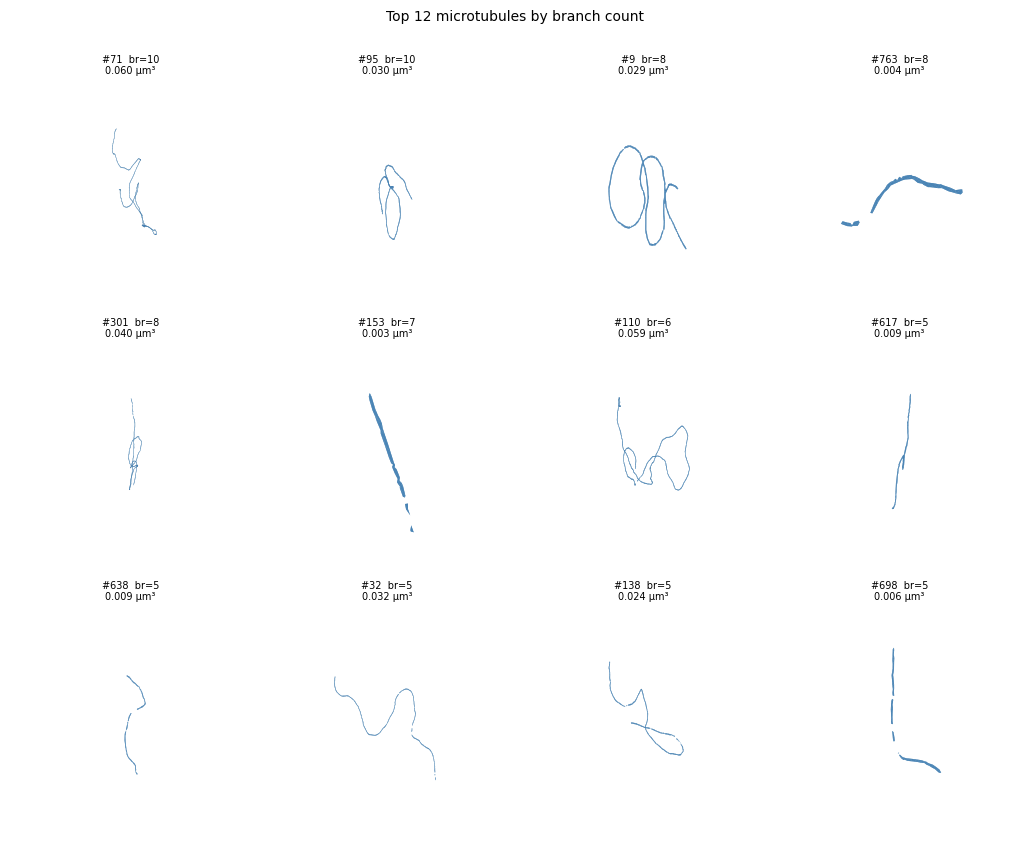

In [6]:
def decode_mesh(b64: str):
    """Decode a mesh_b64 string → (verts float32 [N,3] µm, faces uint32 [M,3]).

    Binary layout (after gzip decompression):
      [uint32 nV][uint32 nF][float32×3 min_xyz][float32×3 scale_xyz]
      [uint16 × nV×3 quantised XYZ][uint32 × nF×3 face indices]
    """
    raw = gzip.decompress(base64.b64decode(b64))
    nV      = int(np.frombuffer(raw, dtype="<u4", count=1, offset=0)[0])
    nF      = int(np.frombuffer(raw, dtype="<u4", count=1, offset=4)[0])
    min_xyz = np.frombuffer(raw, dtype="<f4", count=3, offset=8).copy()
    sca_xyz = np.frombuffer(raw, dtype="<f4", count=3, offset=20).copy()
    vertsQ  = np.frombuffer(raw, dtype="<u2", count=nV * 3, offset=32).reshape(nV, 3).copy()
    faces   = np.frombuffer(raw, dtype="<u4", count=nF * 3, offset=32 + nV * 6).reshape(nF, 3).copy()
    verts   = min_xyz + (vertsQ.astype(np.float32) / 65535.0) * sca_xyz
    return verts, faces


def render_mesh(ax, verts, faces, color="steelblue", alpha=0.88, elev=25, azim=45):
    """Add a mesh to an Axes3D at a consistent camera angle."""
    ctr = verts.mean(axis=0)
    v   = verts - ctr
    r   = float(np.abs(v).max()) * 1.15 or 1.0
    poly = Poly3DCollection(
        v[faces], alpha=alpha, facecolor=color, edgecolor="none", linewidth=0
    )
    ax.add_collection3d(poly)
    ax.set_xlim(-r, r)
    ax.set_ylim(-r, r)
    ax.set_zlim(-r, r)
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()


cols = min(N, 4)
rows = math.ceil(N / cols)
fig  = plt.figure(figsize=(cols * 2.6, rows * 2.8))

for i, (_, row) in enumerate(top.iterrows()):
    ax = fig.add_subplot(rows, cols, i + 1, projection="3d")
    has_mesh = pd.notna(row.get("mesh_b64")) and row.mesh_b64
    if has_mesh:
        verts, faces = decode_mesh(row.mesh_b64)
        render_mesh(ax, verts, faces, color="steelblue")
    else:
        ax.text2D(0.5, 0.5, "no mesh", ha="center", va="center",
                  transform=ax.transAxes, color="#aaa", fontsize=8)
    br  = int(row.branches) if pd.notna(row.branches) else "?"
    vol = f"{row.volume_um3:.3f}" if pd.notna(row.volume_um3) else "?"
    ax.set_title(f"#{int(row.label_id)}  br={br}\n{vol} µm³", fontsize=7, pad=1)

for j in range(len(top), rows * cols):
    fig.add_subplot(rows, cols, j + 1).set_visible(False)

fig.suptitle(f"Top {N} {ENTITY} by branch count", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## Example 4 — Distance from granules to nucleus (per cell)

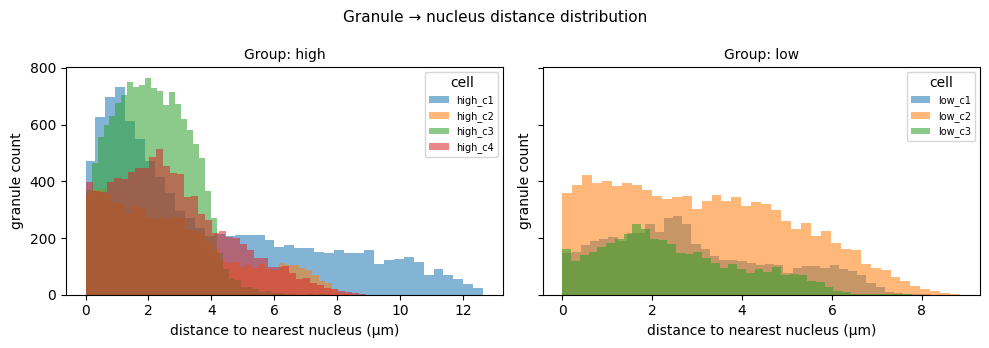

In [7]:
granules = instances[instances.entity_name == "granules"].copy()
dist_col = "distance_to_nucleus_um"

if dist_col not in granules.columns:
    print(f"Column {dist_col!r} not present — available distance columns:")
    print([c for c in granules.columns if c.startswith("distance_")])
else:
    has_groups = "group_id" in granules.columns and granules["group_id"].notna().any()
    groups = sorted(granules["group_id"].dropna().unique()) if has_groups else ["all"]

    fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 3.5),
                             sharey=True, squeeze=False)
    axes = axes[0]

    for ax, grp_name in zip(axes, groups):
        subset = granules if grp_name == "all" else granules[granules["group_id"] == grp_name]
        for cell_id, cell_grp in subset.groupby("cell_id"):
            vals = cell_grp[dist_col].dropna()
            if len(vals):
                ax.hist(vals, bins=40, alpha=0.55, label=cell_id)
        ax.set_xlabel("distance to nearest nucleus (µm)")
        ax.set_ylabel("granule count")
        ax.set_title(f"Group: {grp_name}", fontsize=10)
        ax.legend(fontsize=7, title="cell")

    fig.suptitle("Granule → nucleus distance distribution", fontsize=11)
    plt.tight_layout()
    plt.show()